# Few-Shot Vehicle Classification with DINOv2

## Model

- **Backbone:** DINOv2 Vision Transformer (facebook/dinov2-base)
- **Purpose:** Used as a feature extractor to obtain high-dimensional, semantically rich image embeddings.
- **Why DINOv2?** Self-supervised

In [1]:
import torch
import pandas as pd
from PIL import Image
from transformers import AutoImageProcessor, AutoModel
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Loading DINOv2 model (this is a pure-vision geometric engine)...")
model_id = "facebook/dinov2-base"
processor = AutoImageProcessor.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id)

def get_image_embedding(image_path):
    """Extracts pure spatial/geometric features using DINOv2."""
    image = Image.open(image_path).convert("RGB")
    
    # DINOv2 takes only the image
    inputs = processor(images=image, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs)
        
        # DINOv2 uses the first token 
        img_features = outputs.last_hidden_state[:, 0, :]
        
        # Normalize the vector for perfect distance calculation
        img_features = img_features / img_features.norm(p=2, dim=-1, keepdim=True)
        
    return img_features

def build_memory_bank(context_data):
    print(f"Building DINOv2 Memory Bank from {len(context_data)} reference examples...")
    reference_embeddings = []
    reference_labels = []
    
    for img_path, label in context_data:
        clean_label = label.lower() 
        img_emb = get_image_embedding(img_path) 
        reference_embeddings.append(img_emb)
        reference_labels.append(clean_label)
        
    reference_matrix = torch.cat(reference_embeddings)
    return reference_matrix, reference_labels

def predict_new_image(image_path, reference_matrix, reference_labels):
    """Takes a single test image and finds the closest geometric match."""
    target_img = Image.open(image_path).convert("RGB")
    target_inputs = processor(images=target_img, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**target_inputs)
        target_embedding = outputs.last_hidden_state[:, 0, :]
        target_embedding = target_embedding / target_embedding.norm(p=2, dim=-1, keepdim=True)
    
    # Compare target against the memory bank
    similarities = torch.matmul(target_embedding, reference_matrix.T)
    
    best_match_index = similarities.argmax().item()
    predicted_label = reference_labels[best_match_index]
    
    return predicted_label


if __name__ == "__main__":
    
    # 1.examples 
    examples = [
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-18-28_png.rf.28fc4b45cbb7cc0375a0a1d013da7acb.jpg", "SUV"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-51-53_png.rf.a420675aec9d267a4918e4f6b624b938.jpg", "SUV"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-49-01_png.rf.0a93df9f0be46f0eb90eac2282fc5347.jpg", "SUV"),
        (r"D:\CV_Project\data\cars.v1i.coco\crops\DJI-00760-00001-1-_jpg.rf.ccecf9a0ecc8984c01aaa5fa25516594_ann10.jpg", "SUV"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-17-59_png.rf.f83a7cd8ff5091d85bcd518ba63638ef.jpg", "sedan"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-44-24_png.rf.9ecb63672a6e06a87bf5875b063d626d.jpg", "sedan"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-02-04_png.rf.e778e47b1e388c7441c2fae1c630ec89.jpg", "sedan"),
        (r"D:\CV_Project\data\cars.v1i.coco\crops\DJI_0005-0071_jpg.rf.85e28363e268a259ced325858f5ea023_ann5.jpg", "sedan"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-05-15_png.rf.863275a545cedd225d0060f8e92e7fc7.jpg", "truck"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-04-52_png.rf.0d6db9bde6f4d40692ce4001d5010966.jpg", "truck"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-55-05_png.rf.da96e0c9ae878062bf8cf23474468091.jpg", "truck"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-14-54-08_png.rf.1fcb78dec3616ec5983678d61ed74729.jpg", "truck"),
        (r"D:\CV_Project\data\cars.v1i.coco\train\Screenshot-from-2026-02-12-15-17-07_png.rf.710f4176b646d40b2b99c564172586ca.jpg", "bus"),
        (r"D:\CV_Project\data\cars.v1i.coco\crops\Screenshot-from-2026-02-12-14-59-11_png.rf.b5726dd264543f89310fff9334907344_ann15.jpg", "bus"),
        (r"D:\CV_Project\data\cars.v1i.coco\crops\Screenshot-from-2026-02-12-14-58-26_png.rf.eca11b21c6c6bfd088b7970f4a99e3ac_ann18.jpg", "bus"),
        (r"D:\CV_Project\data\cars.v1i.coco\crops\DJI_0762-00031_jpg.rf.abb1115b71b8b0ff871968c8daf083ea_ann14.jpg", "bus"),
    ]
    
    # 2. test
    my_test_set = [
        (r"C:\Users\YASER\Documents\GitHub\Few-Shot-Vehicle-Detection-\test\sedan.png", "sedan"),
        (r"C:\Users\YASER\Documents\GitHub\Few-Shot-Vehicle-Detection-\test\SUV2.png", "suv"),
        (r"C:\Users\YASER\Documents\GitHub\Few-Shot-Vehicle-Detection-\test\truck.png", "truck"), 
        (r"C:\Users\YASER\Documents\GitHub\Few-Shot-Vehicle-Detection-\test\bus.png", "bus"),     
    ]

    try:
        ref_matrix, ref_labels = build_memory_bank(examples) 
        
        print(f"\nEvaluating {len(my_test_set)} test images...")
        predictions_log = []
        
        for img_path, true_label in my_test_set:
            pred = predict_new_image(img_path, ref_matrix, ref_labels)
            predictions_log.append({
                "image": img_path, 
                "true_label": true_label.lower(), 
                "predicted_label": pred
            })
            
        df = pd.DataFrame(predictions_log)
        
        class_names = ["bus", "sedan", "suv", "truck"]
        accuracy = accuracy_score(df["true_label"], df["predicted_label"])
        
        print(f"\n OVERALL ACCURACY: {accuracy * 100:.1f}%\n")
        print("--- Detailed Classification Report ---")
        print(classification_report(df["true_label"], df["predicted_label"], labels=class_names, target_names=class_names, zero_division=0))
        
        print("--- Confusion Matrix ---")
        print(confusion_matrix(df["true_label"], df["predicted_label"], labels=class_names))

    except Exception as e:
        print(f"\n Execution Error: {e}")

Loading DINOv2 model (this is a pure-vision geometric engine)...


The image processor of type `BitImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Building DINOv2 Memory Bank from 16 reference examples...

Evaluating 4 test images...

 OVERALL ACCURACY: 25.0%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         bus       0.00      0.00      0.00         1
       sedan       0.33      1.00      0.50         1
         suv       0.00      0.00      0.00         1
       truck       0.00      0.00      0.00         1

    accuracy                           0.25         4
   macro avg       0.08      0.25      0.12         4
weighted avg       0.08      0.25      0.12         4

--- Confusion Matrix ---
[[0 0 0 1]
 [0 1 0 0]
 [0 1 0 0]
 [0 1 0 0]]


## Notes

- Results are highly sensitive to data split and sample selection.

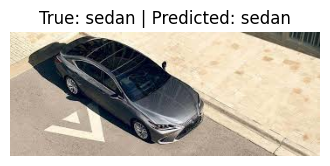

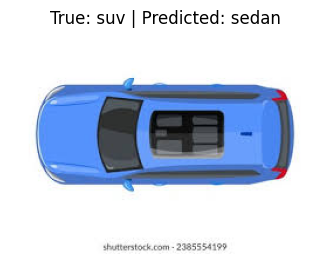

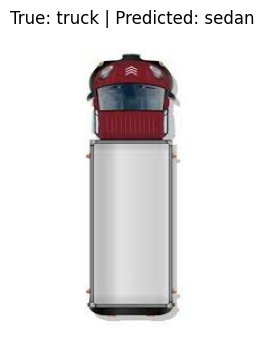

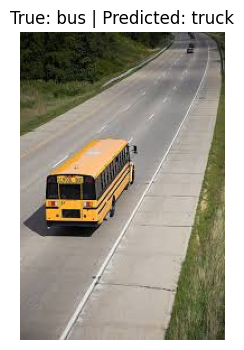

In [2]:
import matplotlib.pyplot as plt
from PIL import Image

# Show results for each test image
for idx, row in df.iterrows():
    img = Image.open(row["image"])
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f"True: {row['true_label']} | Predicted: {row['predicted_label']}")
    plt.axis("off")
    plt.show()